Starting Training...

--- ITERATION 1 ---
Prediction: 3.1000 | Loss: 0.0050
Updated 2x2 Weights (W1):
[[ 0.39   0.095]
 [-0.32   0.39 ]
 [ 0.57   0.685]] 

--- ITERATION 2 ---
Prediction: 2.8137 | Loss: 0.0173
Updated 2x2 Weights (W1):
[[ 0.4083  0.1038]
 [-0.2833  0.4075]
 [ 0.625   0.7113]] 



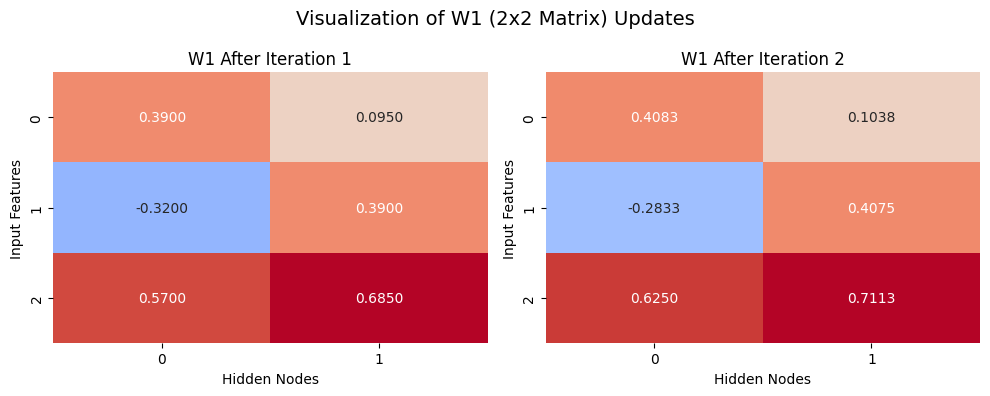

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

X = np.array([[1.0, 2.0, 3.0]])
y = np.array([[3.0]])
lr = 0.1

W1 = np.array([[0.4, 0.1],
               [-0.3, 0.4],
               [0.6, 0.7]])

W2 = np.array([[1.0],
               [0.5]])

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

w1_history = []

print("Starting Training...\n")

for i in range(2):
    print(f"--- ITERATION {i+1} ---")

    Z1 = np.dot(X, W1)
    H1 = relu(Z1)
    y_pred = np.dot(H1, W2)

    loss = 0.5 * np.sum((y_pred - y)**2)
    print(f"Prediction: {y_pred[0][0]:.4f} | Loss: {loss:.4f}")

    dy_pred = y_pred - y
    dW2 = np.dot(H1.T, dy_pred)

    dH1 = np.dot(dy_pred, W2.T)
    dZ1 = dH1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)

    W1 = W1 - (lr * dW1)
    W2 = W2 - (lr * dW2)

    print("Updated 2x2 Weights (W1):")
    print(np.round(W1, 4), "\n")

    w1_history.append(W1.copy())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Visualization of W1 (2x2 Matrix) Updates", fontsize=14)

sns.heatmap(w1_history[0], annot=True, cmap="coolwarm", center=0, fmt=".4f", ax=axes[0], cbar=False)
axes[0].set_title("W1 After Iteration 1")
axes[0].set_xlabel("Hidden Nodes")
axes[0].set_ylabel("Input Features")

sns.heatmap(w1_history[1], annot=True, cmap="coolwarm", center=0, fmt=".4f", ax=axes[1], cbar=False)
axes[1].set_title("W1 After Iteration 2")
axes[1].set_xlabel("Hidden Nodes")
axes[1].set_ylabel("Input Features")

plt.tight_layout()
plt.show()